# Objectives
[Öpik's theory of close encounters](https://www.jstor.org/stable/20488532) of particles in the Solar System with a planet is at the base of modern planetary defense.
In short, he assumes that a particle (such as an asteroid) in the Solar System moves on a heliocentric keplerian ellipse, while the motion of the planet (such as the Earth) is assumed to be circular around the Sun. Whenever the particle gets close to the planet, its motion relative to the planet is treated as a two-body gravitational scattering problem, and it is hence considered to be hyperbolic. 
Modelling such a motion at the encounter is a hard task. However, if the encounter is "close", meaning that the impact parameter $b$ is much smaller than the planet's orbital radius $a_{0}$, namely if $\frac{b}{a_{0}} \lt\lt 1$, we can replace the hyperbolic motion of the particle with a rectilinear motion, effectively exchanging the real behaviour of the particle with its asymptotic, idealized one. Although this might seem hard to figure, it is much easier if you think about it as "zooming" out from the close encounter towards the solar system scale. With these assumptions:

1) the relative velocity of the particle $U$ with respect to the planet at close encounter lies on the incoming asymptote;
2) the encounter happens at the intersection of the two asymptotes;

The theory breaks when either the encounter is a very shallow one, or when the encounter velocity is small (in that case, objects might be captured by the planet, hence the real orbit is not hyperbolic). 

Within this formalism, Öpik provides a way to compute the post-encounter orbital elements as a function of a **subset** ($[a,e,i]$) of the pre-encounter orbital elements $[a,e,i,\Omega,\omega,\nu]$ , the impact parameter, $b$, and the encounter orientation angle, $\psi$. 


The actual impact parameter $b$ and encounter orientation angle $\psi$ can only be determined by a full knowledge of the the **full set** of orbital elements, which might not always be available, especially if the particle (asteroid) has just been discovered and its orbital elemtents are weakly constrained. However Öpik shows that, after a certain time, particles in the Solar System might undergo so many close encounters that the direction of their velocities become equally probable, and thus the same applies to their $\psi$s. For this reason, Öpik (and [Carusi et al.](https://link.springer.com/article/10.1007/BF00050709) after him) write their papers assuming a random distribution of both variables. 

In this example, we show how to compute the post-encounter orbital elements as a function of the pre-encounter elements in the Öpik's formalism, for two different orbits. These are the same orbits probed by Carusi et al, and the retrieved plots are the same they show in their paper. 

# Import relevant modules
As usual, we import the relevant modules. In this case, we will need the **OpikEncounter** class.

In [8]:
from tudatpy.astro.close_encounters.opik_encounters import OpikEncounter
import math
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 
from tudatpy import constants

# Reference Orbital Elements 

Following what was done in Carusi et al, 1990, we pick the following heliocentric orbits, described by two sets of $[a,e,i]$:

1) $a_1, e_1, i_{deg_1} = 0.9, 0.13, 10.0$
2) $a_2, e_2, i_{deg_2} = 0.9, 0.23, 10.0$

In [9]:
AU = constants.ASTRONOMICAL_UNIT  # m
central_body_mass = 5.9722e24  # Earth mass, KG (actual mass, not a ratio)
central_body_radius = 6371.0e3  # Earth radius, meters
central_body_orbital_radius = 1.0 * AU

a_1, e_1, i_deg_1 = 0.9, 0.13, 10.0 # first orbit
a_2, e_2, i_deg_2 = 0.9, 0.23, 10.0 # second orbit

orbits_list = [[a_1, e_1, i_deg_1], [a_2, e_2, i_deg_2]]

# Surface of Variations
[Carusi et al.](https://link.springer.com/article/10.1007/BF00050709) computes the so-called Surface of Variations which, for each element, is a 2D surface telling us how that post-encounter element changed as a function of the pre-encounter elements and $\psi$, $\gamma$, where $\gamma$ is related to the impact parameter $b$ via:

$$ b = \frac{M_{\oplus}}{M_{\odot}}\frac{a_{0}}{U^2 tan(\gamma / 2))} $$

The paper plots the Surface of Variations for $\psi \in [0,2\pi], \gamma \in [0,2\pi]$, so we have to evaluate the above relation to create a grid of $b$ values corresponding to that $\gamma$-interval.

Once we have the grid, we create an OpikEncounter object for each and extract the post-encounter values using the `outgoing_orbital_elements` method. Since [Carusi et al.](https://link.springer.com/article/10.1007/BF00050709) shows the pre-encounter - post-encounter difference on the z-axis, we do the same. For each the two orbits, and for each $\gamma, \psi$ pair, we append the values to the results list.

In [10]:
gamma_values = np.linspace(0, np.pi, 50, endpoint=False)[1:]  # avoid gamma=0 (b=inf) and gamma=pi (b=0)
psi_values = np.linspace(0, 2 * np.pi, 50, endpoint=False)
Gamma, Psi = np.meshgrid(gamma_values, psi_values, indexing="ij")
mass_ratio = central_body_mass / OpikEncounter.SOLAR_MASS

results = []  # one (a, e, i, delta_a, delta_e, delta_i) tuple per orbit
for a, e, i_deg in orbits_list:
    i = math.radians(i_deg)

    seed = OpikEncounter([a, e, i], central_body_mass, central_body_radius, central_body_orbital_radius)
    U = seed.planetocentric_velocity_magnitude_normalized

    b_grid_normalized = mass_ratio / (U**2 * np.tan(gamma_values / 2))
    b_grid_physical = b_grid_normalized * central_body_orbital_radius  # b's constructor arg is in meters

    delta_a = np.empty((len(gamma_values), len(psi_values)))
    delta_e = np.empty((len(gamma_values), len(psi_values)))
    delta_i = np.empty((len(gamma_values), len(psi_values)))
    for gi, b_phys in enumerate(b_grid_physical):
        for pj, psi in enumerate(psi_values):
            encounter = OpikEncounter(
                [a, e, i], central_body_mass, central_body_radius, central_body_orbital_radius,
                b=b_phys, psi=psi,
            )
            a_out, e_out, i_out = encounter.outgoing_orbital_elements
            delta_a[gi, pj] = a_out - a
            delta_e[gi, pj] = e_out - e
            delta_i[gi, pj] = i_out - i

    results.append((a, e, i_deg, delta_a, delta_e, delta_i))

# Plot the Surface of Variations
We can now plot the Surface of Variations. These represent all encounter possibilities in the domains we spanned, but in reality, for each asteroid, the encounter will only have one $[\psi, \gamma]$ pair.

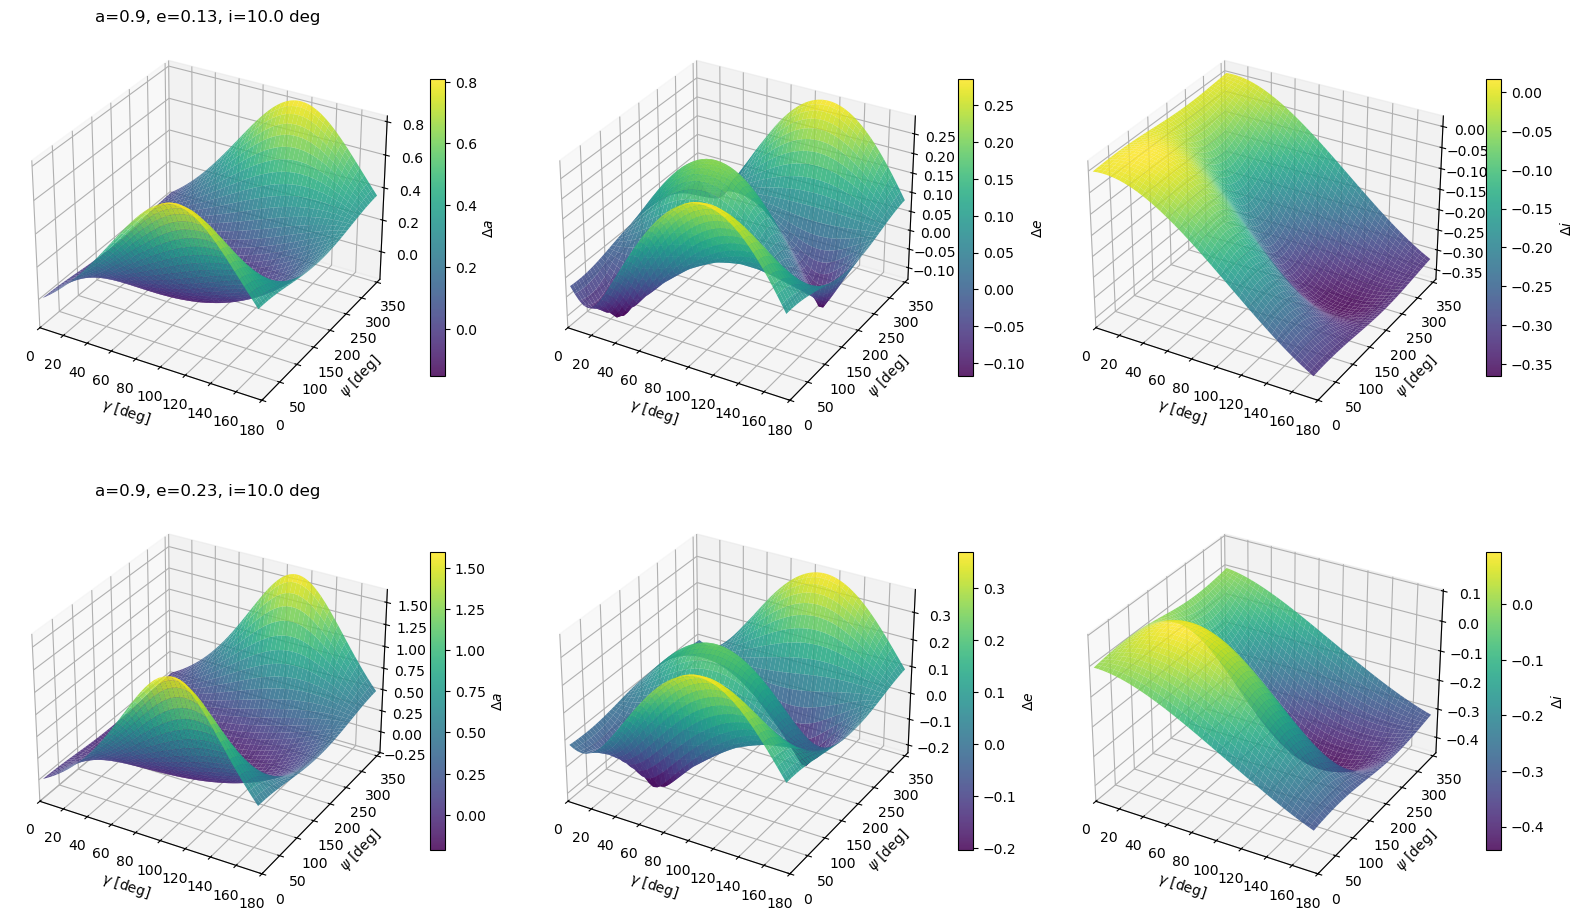

In [11]:
fig = plt.figure(figsize=(16, 5 * len(orbits_list)))
for row, (a, e, i_deg, delta_a, delta_e, delta_i) in enumerate(results):
    surfaces = [
        (delta_a, r"$\Delta a$"),
        (delta_e, r"$\Delta e$"),
        (delta_i, r"$\Delta i$"),
    ]
    for col, (delta, label) in enumerate(surfaces):
        ax = fig.add_subplot(len(orbits_list), 3, row * 3 + col + 1, projection="3d")
        surf = ax.plot_surface(np.degrees(Gamma), np.degrees(Psi), delta, cmap="viridis", edgecolor="none", alpha=0.85)
        ax.set_xlabel(r"$\gamma$ [deg]")
        ax.set_ylabel(r"$\psi$ [deg]")
        ax.set_zlabel(label)
        ax.set_xlim(0, 180)
        ax.set_ylim(0, 360)
        if col == 0:
            ax.set_title(f"a={a}, e={e}, i={i_deg} deg")

        fig.colorbar(surf, ax=ax, shrink=0.6, label=label)
plt.tight_layout()
plt.show()